# Exploration de la qualité des données

Nous devons vérifier si les données collectées sont suffisamment fiables et pertinentes pour notre sujet.

## 0. Import de fonctions utiles à l'importation des données

Avant de procéder à l'acquisition des données, il est essentiel de configurer notre environnement de travail. Dans une optique de **reproductibilité** et de **clarté du code**, la logique technique (les fonctions de téléchargement) a été déportée dans un dossier dédié nommé `/fonctions`, composé de fichiers Python. 

La cellule suivante initialise cette connexion en ajoutant le dossier des scripts au chemin système de Python et en important l'ensemble des dépendances nécessaires.

In [2]:
import sys
import os
import pandas as pd
from pathlib import Path

# On connecte le notebook à tous les fichiers inclus dans le dossier /fonctions
sys.path.append(os.path.abspath("../fonctions"))

# On importe toutes les fonctions dans le fichier imports.py
from utils import * # type: ignore

## 1. Analyse de la qualité des données (Transfermarkt)

Avant d'intégrer les statistiques de performance, il est impératif de valider la fiabilité de notre variable cible : la **valeur marchande**. 
Cette phase permet de comprendre la structure du marché, d'identifier les segments de joueurs et de nettoyer les données pour garantir la précision du futur modèle prédictif.

### 0. Source des données et traçabilité
Afin de garantir la reproductibilité de cette analyse, les données sont extraites directement via l'API Kaggle. 

* **Dataset :** [Football Data from Transfermarkt](https://www.kaggle.com/datasets/davidcariboo/player-scores)
* **Identifiant :** `davidcariboo/player-scores`
* **Dernière mise à jour du dataset :** 01/04/2026

In [7]:
identifiant = "davidcariboo/player-scores"
date_update = get_kaggle_dataset_last_update(identifiant)
date_str = date_update.strftime("%Y-%m-%d")

Dataset trouvé : davidcariboo/player-scores
Dernière mise à jour : 2026-04-01 09:41:00.553000


### 1. Analyse Exploratoire de la Population

L'examen initial des distributions révèle trois facteurs principaux concernant la valorisation des joueurs :

* **Distribution des Prix :** On observe un comportement assez particulier. La majorité des joueurs se situe sous les 5M€, tandis que très peu de joueurs dépassent les 100M€. Cette asymétrie impose une approche logarithmique pour la modélisation.
* **Courbe des Âges :** La distribution suit une courbe de Gauss centrée sur **25-28 ans**. La valeur marchande étant liée au potentiel de revente et à la qualité physique, l'âge sera une variable explicative non-linéaire majeure.
* **Segmentation par Ligue (Big 5) :** Les boxplots confirment un marché à plusieurs vitesses. La **Premier League** affiche non seulement la médiane la plus haute mais aussi la plus forte concentration de joueurs plus chers (les outliers). À talent égal, le facteur "Ligue" devrait influencer drastiquement le prix final.

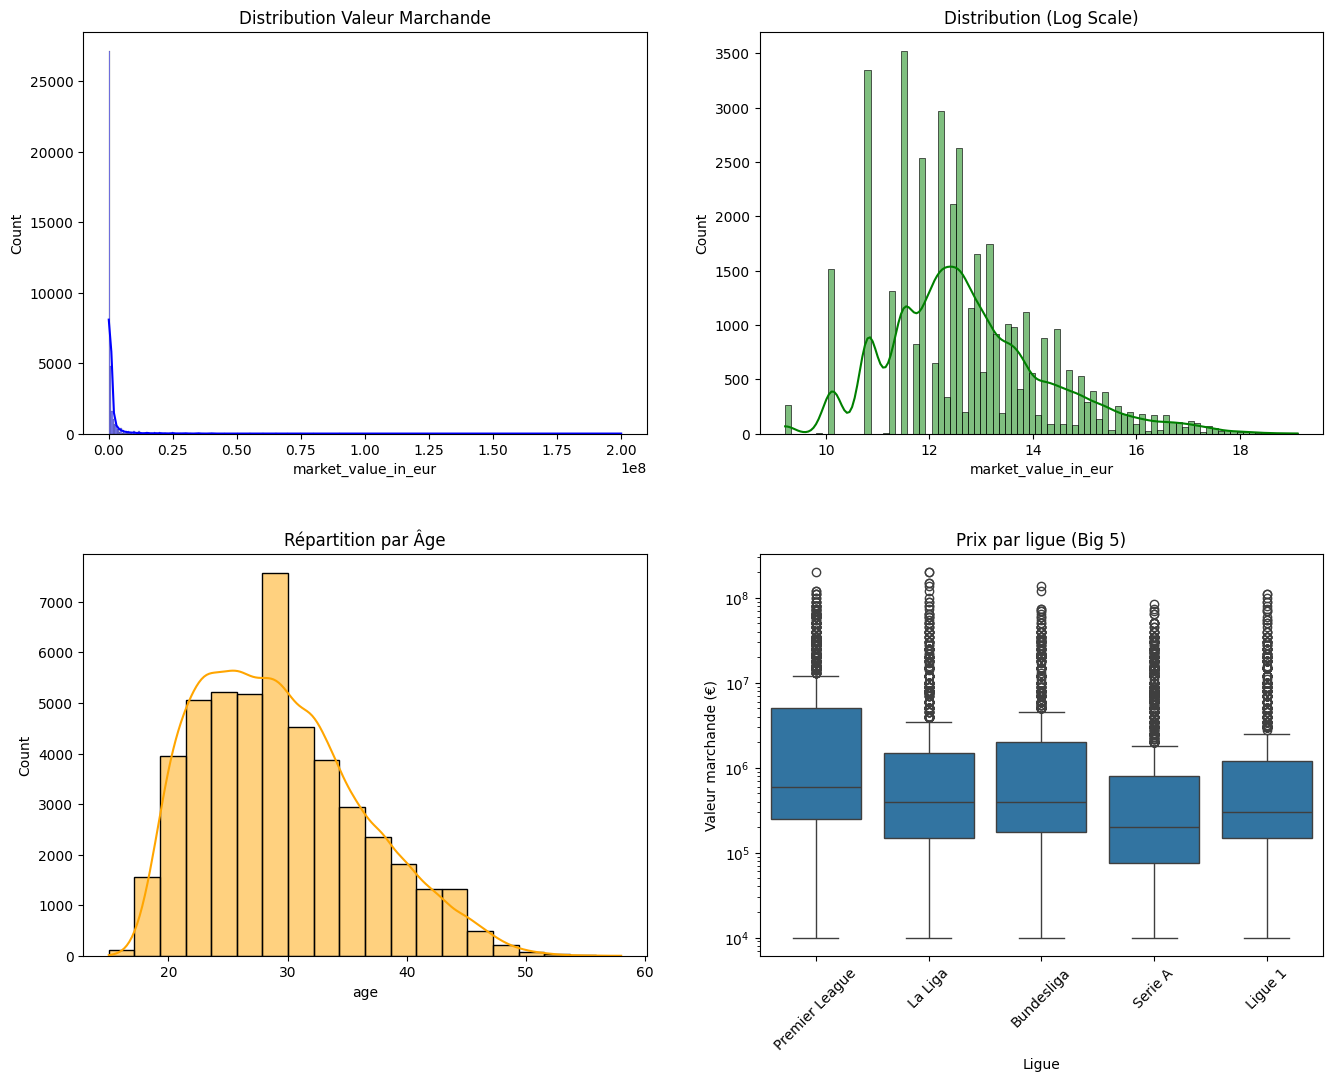

In [8]:
# Chargement des fichiers
df_players = pd.read_csv("../data/transfermarkt_datasets/players.csv")
df_clubs = pd.read_csv("../data/transfermarkt_datasets/clubs.csv")

# Appel de la fonction avec les deux dataframes
plot_transfermarkt_quality(df_players, df_clubs)

### 2. Fraîcheur et Pertinence Temporelle

Le graphique des dates de dernières évaluations est un indicateur de fiabilité. En effet, une partie du dataset contient des prix n'ayant pas été mis à jour depuis plusieurs années (2012-2022). Ces données ne sont plus analysables statistiquement car elles ne correspondent plus aux performances actuelles.

Nombre total d'évaluations dans l'historique : 616377
Nombre de joueurs uniques évalués : 39361
------------------------------
Date de l'évaluation la plus ancienne (historique) : 2000-01-20
Date de l'évaluation la plus récente (marché actuel) : 2026-03-30


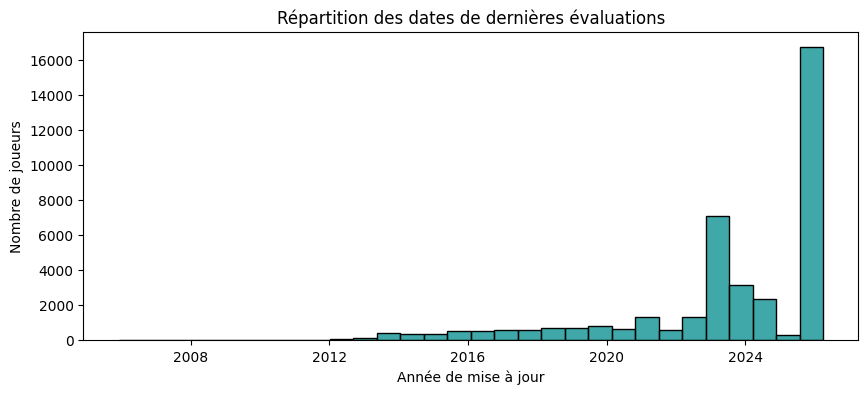

,player_id,date,market_value_in_eur,current_club_name,current_club_id,player_club_domestic_competition_id
4565,16733,2005-12-02,100000,Malmö FF,678.0,DK1
15907,73096,2008-04-16,50000,CA Metropolitano,982.0,PO1
31935,62553,2009-10-25,200000,Hibernian FC,2759.0,SC1
34306,134354,2009-12-28,50000,Unknown,498.0,BE1
37808,144619,2010-03-15,25000,Spartak Moskow II,232.0,RU1
...,...,...,...,...,...,...
616287,673173,2026-03-30,1400000,IF Elfsborg,1101.0,SE1
616288,685657,2026-03-30,2000000,BK Häcken,1109.0,SE1
616289,688019,2026-03-30,800000,IF Brommapojkarna,1092.0,SE1
616283,666951,2026-03-30,900000,IFK Göteborg,801.0,SE1


In [9]:
# Chargement de l'historique des valeurs marchandes
df_valuations = pd.read_csv("../data/transfermarkt_datasets/player_valuations.csv")

# Convertir la colonne date en format datetime
get_latest_player_valuations(df_valuations, plot_freshness=True)

### 3. Diagnostic de l'Intégrité des Données
Le nettoyage technique repose sur trois vérifications critiques :

* **Valeurs manquantes (NaN) :** 18% des joueurs n'ont pas de valeur cible (valeur marchande) et sont donc exclus. Les statistiques internationales manquantes sont imputées à `0` (joueurs non-sélectionnés).
* **Doublons :** Seuls 2 doublons (Nom/Date de naissance) ont été détectés, prouvant la robustesse du dataset.
* **Intégrité référentielle (orphelins) :** 135 joueurs possèdent un historique de prix mais aucune fiche de profil associée.

c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\predict_vm_football\fonctions\utils.py:166: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_pct.index, y=missing_pct.values, palette="Reds_r")


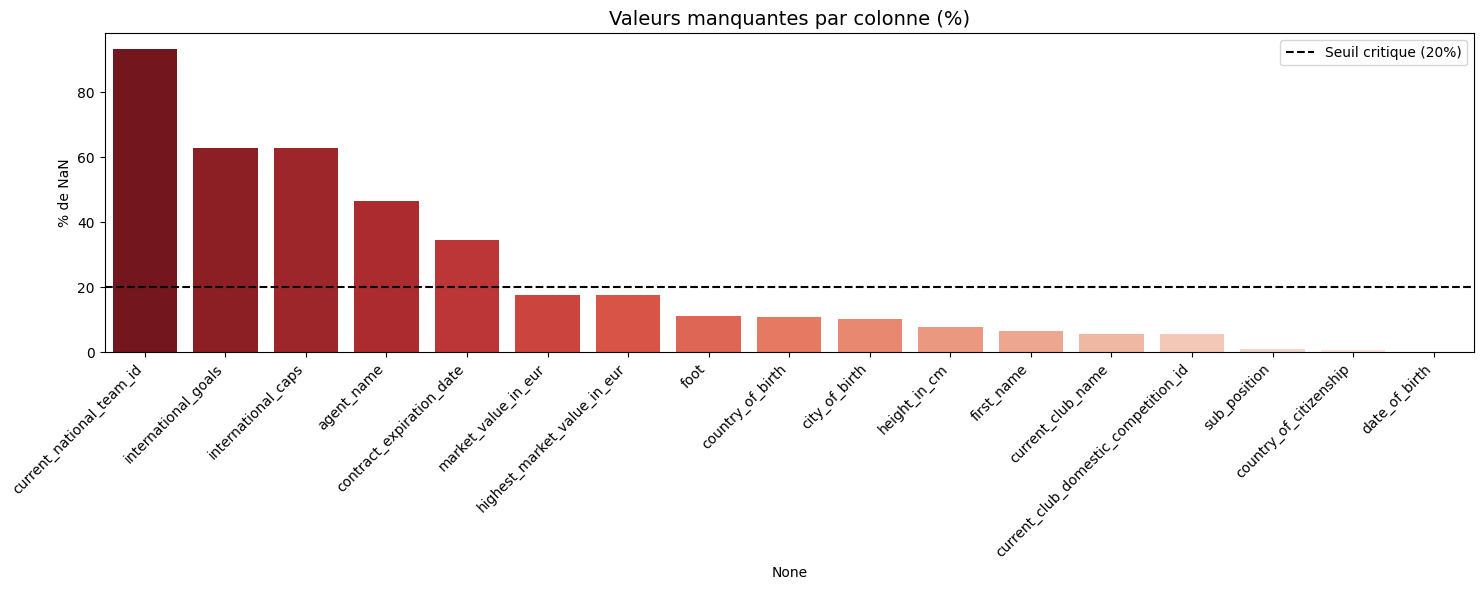

In [11]:
# 2. Analyse des valeurs manquantes (Contrats et Cible)
check_all_missing_values(df_players)

In [12]:
check_player_duplicates(df_players)

2 doublons potentiels détectés (même nom et date de naissance).


,player_id,first_name,last_name,name,last_season,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,...,agent_name,image_url,international_caps,international_goals,current_national_team_id,url,current_club_domestic_competition_id,current_club_name,market_value_in_eur,highest_market_value_in_eur
23679,398057,João,Ricciulli,João Ricciulli,2018,1038,joao-ricciulli,Guinea-Bissau,Bissau,Guinea-Bissau,...,Evlon Sports & Mgmt,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/joao-ricciulli...,IT1,UC Sampdoria,25000.0,100000.0
26162,461923,João,Ricciulli,João Ricciulli,2022,2420,joao-ricciulli,NaN,Bissau,NaN,...,NaN,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/joao-ricciulli...,PO1,Vitória Sport Clube,100000.0,100000.0


In [13]:
# On vérifie l'intégrité avant d'aller plus loin
orphans_list = check_referential_integrity(df_players, df_market_final)

Analyse de l'intégrité référentielle :
- Joueurs dans le fichier Profil : 47702
- Joueurs dans le fichier Valuations : 16743
----------------------------------------
ALERTE : 130 joueurs ont des prix mais n'ont pas de profil.
Ces prix seront perdus lors de la jointure (Merge).
Exemples d'IDs orphelins : [910848, 552960, 131074, 910851, 751104]


## 2. Analyse de la qualité des données (FBref)

### 0. Source des données et traçabilité
Afin de garantir la reproductibilité de cette analyse, les données sont extraites directement via l'API Kaggle. 

* **Dataset :** [Football Players Stats (2025-2026)](https://www.kaggle.com/datasets/hubertsidorowicz/football-players-stats-2025-2026)
* **Identifiant :** `hubertsidorowicz/football-players-stats-2025-2026`
* **Dernière mise à jour du dataset :** 2026-04-28

In [14]:
# L'identifiant du Kaggle
identifiant = 'hubertsidorowicz/football-players-stats-2025-2026'

# La date de dernière mise à jour
date_update = get_kaggle_dataset_last_update(identifiant)

Dataset trouvé : hubertsidorowicz/football-players-stats-2025-2026
Dernière mise à jour : 2026-04-28 08:52:47.730000


### 1. Filtrage de représentativité

Le dataset FBref brut contient l'intégralité des joueurs ayant foulé la pelouse, même pour quelques secondes. Pour garantir la robustesse statistique de notre modèle, un filtrage sur le temps de jeu est impératif.

* **Seuil de fiabilité :** Nous avons fixé un minimum de **450 minutes jouées** (l'équivalent de 5 matchs complets). 
* **Impact sur le volume :** Ce filtre réduit le dataset de **30.7%**, passant de 2 751 à 1 907 joueurs. Bien que la perte de données semble importante, elle est nécessaire pour éliminer le "bruit" statistique.
* **Correction des biais (Exemple concret) :** * Avant filtrage, des joueurs comme *Marin Ljubicic* affichaient un ratio de **8.18 buts / 90 min** (car il a marqué 2 buts en seulement 22 minutes). 
    * En conservant ces profils, le modèle d'IA apprendrait des corrélations erronées, pensant que l'efficacité est décorrélée du temps de jeu réel.
* **Segmentation des postes :** Nous avons isolé **1 777 joueurs de champ** et **130 gardiens de but**. Cette séparation est fondamentale car les métriques de performance (tacles, buts vs arrêts, clean sheets) ne sont pas comparables mathématiquement.

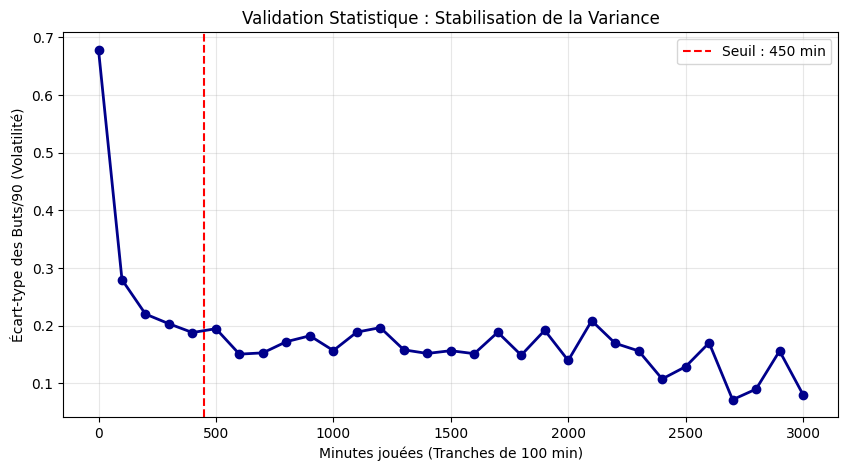

Preuve mathématique : Réduction du bruit de 66.3%
FILTRAGE TERMINÉ
- Joueurs initiaux : 2761
- Joueurs conservés : 1927 (Soit 1793 joueurs de champ)


In [15]:
# Chargement initial
df_fbref = pd.read_csv("../data/fbref_datasets/players_data-2025_2026.csv")

# 2. Appel de la fonction (Maintenant il connaît df_fbref)
df_field, df_keepers = process_fbref_performance(df_fbref, min_minutes_played=450)

# 3. Analyse spécifique du biais (Le petit plus pour ton rapport)
df_low_time = df_fbref[(df_fbref['Min'] < 450) & (df_fbref['Min'] > 0)].copy()

### 2. Élagage et Sélection des Variables (Audit Qualité)
Le dataset FBref original est une agrégation complexe de plusieurs rapports (Standard, Shooting, Passing, etc.), ce qui génère une redondance massive d'informations et de nombreuses cellules vides.

* **Suppression des colonnes "vides" :** En appliquant un seuil de **80% de valeurs manquantes**, **24 colonnes** ont été supprimées. Il s'agissait principalement de métriques spécifiques aux gardiens de but, non renseignées pour les joueurs de champ.
* **Nettoyage des redondances techniques :** Nous avons identifié et supprimé **31 colonnes redondantes**. Ce sont les variables générées lors de la fusion des fichiers sources (identifiables par les suffixes `_stats_` ou les répétitions de `Rk`, `Nation` et `Born`).
* **Optimisation de la structure :** Le dataset est passé de **102 à 47 colonnes**. Cette réduction de **54%** de la dimensionnalité permet de ne conserver que les indicateurs de performance pure (Gls, Ast, etc.) tout en facilitant la lecture et le traitement par les algorithmes d'IA.
* **Bilan :** Nous disposons désormais d'un vecteur de caractéristiques (features) dense et pertinent pour chaque joueur.

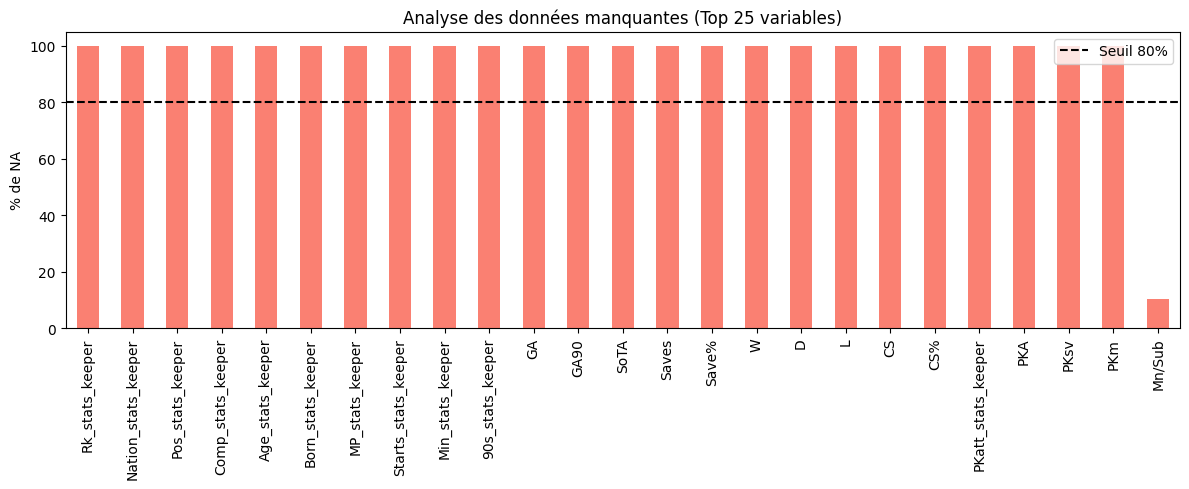

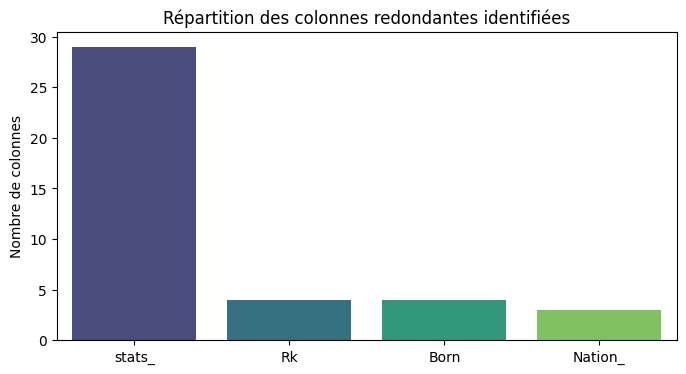

ÉLAGAGE DES VARIABLES TERMINÉ
---------------------------------------------------
- Colonnes initiales : 102
- Supprimées (> 80% NA) : 24
- Supprimées (Redondances) : 31
- Colonnes finales conservées : 47


In [15]:
# Utilisation de la fonction sur tes joueurs de champ déjà filtrés
df_fbref_final = prune_fbref_columns(df_field, threshold=0.80)

### 3. Intégrité et Unicité (Gestion des Transferts)
Dans le dataset FBref, un joueur ayant changé de club ou ayant été prêté durant la saison apparaît sur plusieurs lignes (une entrée par club). 

* **Problématique du doublon :** Sans traitement, ces joueurs sont comptabilisés comme deux entités distinctes avec des statistiques partielles. Par exemple, **Simon Adingra** possédait deux lignes (une avec Sunderland, une avec Monaco) avec des volumes de jeu et des buts différents.
* **Méthodologie de consolidation :** * Nous avons identifié **26 joueurs** présentant des entrées multiples.
    * Afin de garantir la représentativité de la performance, nous avons appliqué une règle de sélection stricte : seule la ligne présentant le **temps de jeu le plus élevé (`Min`)** est conservée.
* **Résultat de l'apurement :** * Le volume est passé de 1 777 à **1 751 lignes**.
    * Cette étape assure l'atomicité du dataset : **un joueur = une ligne**.
* **Bilan :** Le dataset est désormais prêt pour une analyse individuelle cohérente, chaque ligne représentant la période la plus significative de la saison pour chaque athlète.

In [16]:
# On applique la résolution sur le dataset nettoyé
df_fbref_final = resolve_player_duplicates(df_fbref_final)

# Vérification rapide sur un joueur connu pour avoir bougé (si applicable)
# print(df_fbref_final[df_fbref_final['Player'].str.contains('NomDuJoueur')])

Joueurs avec plusieurs lignes (transferts/doublons) : 26
Bilan de l'unicité :
- Lignes traitées : 1777
- Lignes après dédoublonnage : 1751
- 'Doublons de transfert' supprimés : 26
----------------------------------------


### 4. Normalisation des Types et Formats
Pour que les données de performance soient exploitables par nos algorithmes et compatibles avec le dataset Transfermarkt, nous avons procédé à une normalisation structurelle :

* **Conversion de l'Âge :** Le format textuel complexe de FBref (ex: `27-125`) a été transformé en format **float64**. Cette conversion est indispensable pour inclure l'âge comme variable quantitative dans nos futurs modèles de régression.
* **Imputation des valeurs manquantes :** Grâce à une analyse sémantique des colonnes, les `NaN` ont été remplacés par **0** (imputation logique). Dans le contexte du football, une absence de donnée sur un tir ou une passe signifie que l'action n'a pas eu lieu, et non que l'information est inconnue.
* **Bilan d'intégrité :** Le dataset final ne contient plus **aucune valeur manquante (0 NaN)** sur les 47 colonnes conservées, garantissant une stabilité totale pour les calculs matriciels à venir.

In [17]:
# Application de la normalisation sur ton dataset unique
df_fbref_final = normalize_fbref_formats(df_fbref_final)

# Vérification rapide
print(f"Format final de la colonne Age : {df_fbref_final['Age'].dtype}")

Normalisation des formats terminée.
- Colonnes numériques imputées : 42
- Valeurs manquantes totales restantes : 0
Format final de la colonne Age : float64


### 5. Audit des Outliers et Cohérence Statistique
La dernière étape de notre protocole de nettoyage consiste à valider les valeurs extrêmes pour s'assurer qu'elles reflètent la réalité sportive et non une anomalie de saisie.

* **Performance offensive :** L'analyse des boxplots révèle des outliers significatifs sur le nombre de buts et de tirs. Après vérification, ces points correspondent aux "Top Players" mondiaux (ex: attaquants de classe mondiale). Ces données sont conservées car elles sont essentielles pour que l'IA apprenne à valoriser l'élite.
* **Distribution de l'âge :** Aucune valeur aberrante n'a été détectée (ex: joueur de 10 ans ou 60 ans). La population étudiée est cohérente avec les standards du football professionnel.
* **Validation du temps de jeu :** Grâce au filtre initial de 450 minutes, les ratios par 90 minutes (Gls/90, Sh/90) sont stabilisés et ne présentent plus de pics mathématiques artificiels.

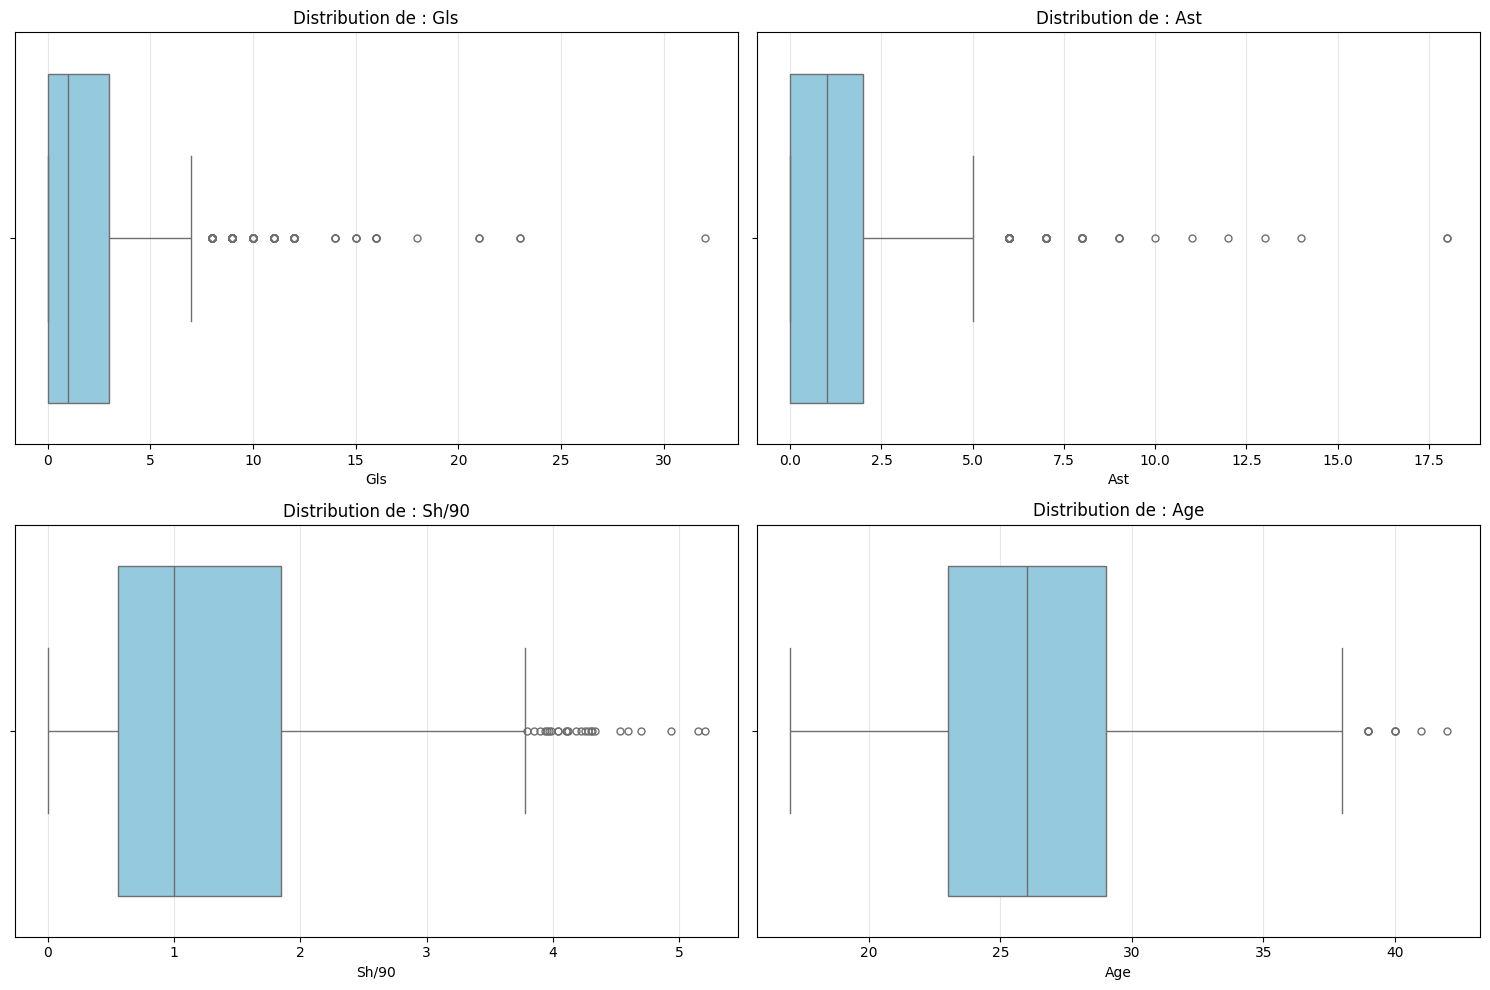

Top 5 'Outliers' Performance (Gls) :
              Player            Squad  Gls   Min
1275      Harry Kane    Bayern Munich   32  2107
1643   Kylian Mbappé      Real Madrid   23  2227
1063  Erling Haaland  Manchester City   23  2593
2499     Igor Thiago        Brentford   21  2832
1784    Vedat Muriqi         Mallorca   21  2498
----------------------------------------


In [18]:
# Lancement de l'audit sur ton dataset nettoyé
audit_fbref_outliers(df_fbref_final, metrics=['Gls', 'Ast', 'Sh/90', 'Age'])

## 3. Analyse de la qualité des données (Statsbomb)

In [19]:
df_sb_matches = pd.read_feather("../data/statsbomb_datasets/data/all_matches.feather")

# Exécution pour voir la date de mise à jour
recent_match, update_time = get_statsbomb_last_update(df_sb_matches)

FRAÎCHEUR DES DONNÉES STATSBOMB
-------------------------------------------
• Match le plus récent au calendrier : 27/07/2025
• Dernière mise à jour du flux API  : Non disponible (colonne absente)
-------------------------------------------


### 1. Bilan des Données StatsBomb

L'analyse des fichiers `.feather` permet de valider la structure des données de performance tactique. Un point d'attention majeur a été identifié concernant la liaison des tables.

***État de Santé Global***
Le dataset est techniquement sain sur le plan de la complétude brute, mais présente une rupture de lien logique :

| Métrique | Résultat
| :--- | :--- | :--- |
| **Matchs répertoriés** | 3 464
| **Entrées joueurs (Lineups)** | 131 901
| **Doublons identifiés** | 0 
| **Liaison Matchs ↔ Lineups** | **0% de correspondance**

***Diagnostic de l'Intégrité***
L'audit indique que **3 464 matchs n'ont pas de compositions associées**, ce qui correspond à la totalité du dataset `all_matches`. 

> **Hypothèse technique :** Ce problème survient généralement lorsque les `match_id` dans `all_lineups` sont stockés sous un format différent (ex: *String* vs *Int*) ou si le fichier des lineups provient d'une extraction différente de celle des matchs. Il sera impératif de normaliser le type de la colonne `match_id` avant toute fusion.

***Distribution des Compétitions***
Malgré le problème de liaison, le volume par ligue est significatif et couvre bien le "Big Five" européen :

* **La Liga** : 868 matchs
* **Ligue 1** : 435 matchs
* **Premier League** : 418 matchs
* **Serie A** : 381 matchs
* **Bundesliga** : 340 matchs

***Conclusion et Action***
Le dataset **StatsBomb** est riche mais actuellement "siloté". 
**Action requise :** Vérifier le type de données (Dtype) de la colonne `match_id` dans les deux DataFrames. Une simple conversion `df['match_id'].astype(int)` devrait résoudre le problème d'intégrité et permettre de lier les 131 000 lignes de joueurs aux rencontres.

In [20]:
# Définition du chemin (adapte selon ton architecture)
folder = Path("../data/statsbomb_datasets/data")

# 1. Chargement des fichiers Feather
df_sb_matches = pd.read_feather(folder / "all_matches.feather")
df_sb_lineups = pd.read_feather(folder / "all_lineups.feather")
df_sb_competitions = pd.read_feather(folder / "competitions_statsbomb.feather")

# 2. Exécution de l'Audit
stats_report = audit_statsbomb_data(df_sb_matches, df_sb_lineups)


AUDIT STATSBOMB
-------------------------------------------
• Matchs   : 3464 lignes | Doublons : 0
• Lineups  : 131901 lignes | Doublons : 0
• Intégrité: 3464 match(s) sans composition d'équipe
-------------------------------------------
Aucune valeur manquante sur les identifiants clés.

Top 5 Compétitions (StatsBomb) :
competition.competition_name
La Liga           868
Ligue 1           435
Premier League    418
Serie A           381
1. Bundesliga     340
Name: count, dtype: int64
-------------------------------------------


### 2. Analyse de la Couverture Temporelle (Post-2020)

Cette analyse valide la profondeur historique du dataset **StatsBomb** après application du filtre "ère moderne".

***Résumé de la Période***
Le dataset filtré couvre plus de **5 ans** de données footballistiques, permettant de capturer les évolutions tactiques récentes.

* **Fenêtre** : du 05/07/2020 au 27/07/2025
* **Volume** : 760 matchs analysables
* **Étendue** : 1 848 jours

***Distribution par Saison (Top 5)***
On observe une accélération de la collecte de données sur les saisons civiles et les exercices récents :

| Saison | Nombre de Matchs |
| :--- | :---: |
| **2023** | 122 |
| **2024** | 83 |
| **2023/2024** | 34 |
| **2022/2023** | 32 |
| **2025** | 31 |

Bien que le nombre total de matchs (760) soit inférieur à d'autres datasets, la qualité "événementielle" de StatsBomb compense cette quantité par une densité d'information supérieure (xG, pressions, positions).

***Conclusion***
Le dataset est désormais aligné sur une période temporelle cohérente avec les autres sources.

In [21]:
# Analyse temporelle
sb_start, sb_end = check_statsbomb_temporal_coverage(df_sb_matches)

COUVERTURE TEMPORELLE STATSBOMB (Depuis 01/07/2020)
-------------------------------------------
• Premier match : 05/07/2020
• Dernier match  : 27/07/2025
• Étendue        : 1848 jours (env. 5.1 ans)
• Nb de matchs   : 760
-------------------------------------------

Matchs par Saison :
season.season_name
2025          31
2024          83
2023/2024     34
2023         122
2022/2023     32
Name: count, dtype: int64


### 3. Analyse Graphique StatsBomb

***Répartition par Compétition***
Le dataset est dominé par **La Liga**, suivie d'un volume équilibré pour les autres ligues du **Big Five** (Ligue 1, Premier League, Serie A, Bundesliga). La présence de compétitions internationales et assure cependant une bonne diversité.

***Dynamique des Scores***
La distribution des buts suit une **loi de Poisson** cohérente :
* **Pic de fréquence** : 1 but par équipe.
* **Avantage domicile** : La courbe des scores à domicile est légèrement plus élevée et étendue.
* **Réalisme** : Les scores élevés sont rares, confirmant l'absence d'anomalies majeures.

***Conclusion***
Les données sont **statistiquement saines**. La distribution des buts valide la fiabilité des résultats pour la modélisation.

c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\predict_vm_football\fonctions\utils.py:1073: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_matches, y='competition.competition_name',


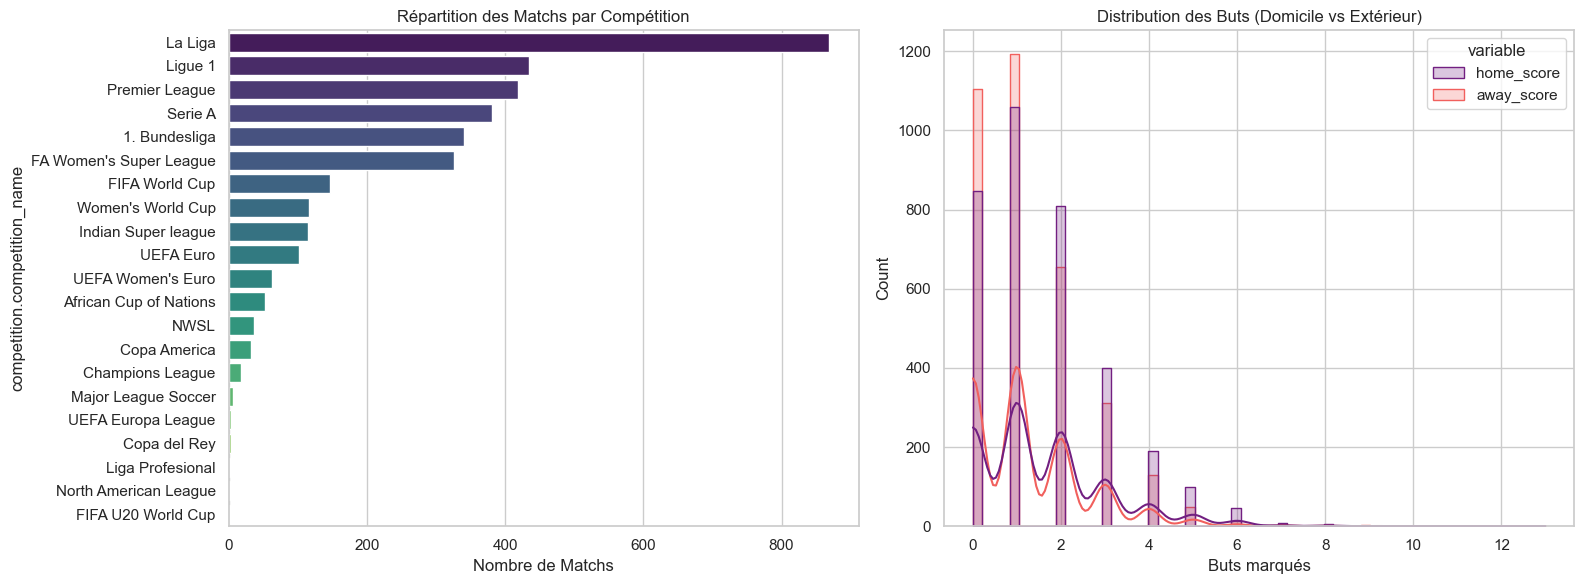

In [22]:
# 1. Visualisation des compétitions et des scores
plot_statsbomb_distributions(df_sb_matches)

## 4. Analyse de la qualité des données (football-data)

### 0. Source des Données et Traçabilité
Afin de garantir la reproductibilité de cette analyse, les données sont extraites directement via le site football-data.co.uk.

* **Dataset :** [Historical Football Results and Betting Odds Data](https://www.football-data.co.uk/data.php)
* **Dernière mise à jour du dataset :** 2026-04-27

Pour constater si nos données sont mises à jour régulièrement, nous pouvons regarder la date de dernière mise à jour.

In [23]:
# Vérification des mises à jour
df_status = check_football_data_updates(season="2526")

# Affichage élégant
display(df_status)

Vérification des mises à jour (Saison 2526)...



,Compétition,Code,Dernière mise à jour
0,Premier League,E0,"Tue, 28 Apr 2026 11:08:53 GMT"
1,Liga,SP1,"Tue, 28 Apr 2026 11:08:54 GMT"
2,Serie A,I1,"Tue, 28 Apr 2026 11:08:55 GMT"
3,Ligue 1,F1,"Mon, 27 Apr 2026 11:37:04 GMT"
4,Bundesliga,D1,"Mon, 27 Apr 2026 11:37:02 GMT"


### 1. Nettoyage Football-Data

Le dataset a été filtré pour ne conserver que les indicateurs de performance et les cotes principales.

| Métrique | Valeur |
| :--- | :--- |
| **Colonnes initiales** | 163 |
| **Colonnes finales** | 25 |
| **Matchs validés** | 5 024 |

**Bilan :** Suppression de **85%** des colonnes inutiles. Les données sont prêtes pour être analysées.

In [24]:
# On charge avec low_memory=False car le fichier est large et hétérogène
df_fd_raw = pd.read_csv("../data/football_data.csv", low_memory=False)

# Nettoyage via la fonction
df_fd = process_football_data(df_fd_raw)

Audit Football-Data :
- Nombre de colonnes initiales : 163
- Nombre de colonnes après élagage : 25
- Matchs validés : 5024
------------------------------


### 2. Intégrité des Données

L'audit de qualité final confirme la robustesse du dataset **Football-Data** après traitement. Les données sont structurellement saines et prêtes pour la phase de modélisation.

**Analyse de la Complétude (NA)**
Le dataset présente un état de complétude quasi parfait. 
* **Observation** : Une seule ligne (1 match) présente des valeurs manquantes sur l'ensemble des statistiques de jeu (Tirs, Corners, Fautes, Cartons).
* **Action préconisée** : Suppression par `dropna()` de cette ligne unique pour garantir un entraînement du modèle sur des statistiques 100% réelles.

**Validation de la Cohérence Logique**
L'intégrité métier a été vérifiée via quatre points de contrôle critiques :

| Point de Contrôle | Statut | Résultat |
| :--- | :---: | :--- |
| **Scores vs Résultats (FTR)** | ✅ | 100% de cohérence (ex: score 2-1 = 'H') |
| **Validité des Scores** | ✅ | Aucun score négatif détecté |
| **Anomalies de Cotes** | ✅ | Aucune cote aberrante (< 1.0) |
| **Unicité des Matchs** | ✅ | **0 doublon** détecté |


Le dataset est considéré comme **"Clean"**. L'absence totale d'erreurs de résultat et de doublons assure que le modèle ne subira aucun biais lié à des erreurs de saisie humaine dans la source de données.

In [25]:
df_na = audit_data_quality(df_fd)

ANALYSE QUALITÉ :
-------------------------------
• Doublons détectés : 0
-------------------------------
Colonnes avec données manquantes :
Variable  Nombre de NA
      HS             1
      AS             1
     HST             1
     AST             1
      HF             1
      AF             1
      HC             1
      AC             1
      HY             1
      AY             1
      HR             1
      AR             1
-------------------------------


In [26]:
# Lancement de l'audit final sur ton dataframe nettoyé
coherence_report = audit_football_data_coherence(df_fd)

Audit de cohérence terminé :
-------------------------------------------
• Erreurs de score (négatifs)  : 0
• Erreurs de résultat (FTR)    : 0
• Anomalies sur les cotes      : 0
• Matchs en double             : 0
-------------------------------------------
Intégrité des données : PARFAITE


### 3. Analyse de la Couverture et des Ligues

Ce dernier contrôle permet de valider l'équilibre du dataset et la profondeur historique disponible pour l'entraînement du modèle.

Le dataset couvre une période charnière de près de **3 ans**, incluant les saisons complètes depuis 2023/2024 et les matchs les plus récents de 2026.

* **Période :** du 11/08/2023 au 23/04/2026
* **Profondeur :** 986 jours de données historiques.
* **Intérêt :** Cette durée est idéale pour capturer la saisonnalité et l'évolution à long terme des performances des clubs.



Les données sont équitablement réparties entre les **5 grands championnats européens (Big Five)**.

| Compétition | Nombre de Matchs | Part (%) |
| :--- | :---: | :---: |
| **Premier League** | 1 092 | ~21.7% |
| **Serie A** | 1 090 | ~21.7% |
| **Liga** | 1 080 | ~21.5% |
| **Bundesliga** | 882 | ~17.6% |
| **Ligue 1** | 880 | ~17.5% |
| **TOTAL** | **5 024** | **100%** |

**Note sur le volume :** La différence de volume (Bundesliga et Ligue 1) s'explique structurellement par le passage à **18 clubs** (34 journées contre 38 pour les autres ligues). Cette répartition reflète parfaitement la réalité du calendrier européen.

***Conclusion de l'étape***
Les données sont **synchronisées, nommées et équilibrées**. Nous disposons d'une base solide de plus de 5 000 matchs pour débuter nos analyses statistiques.

In [27]:
# Vérification pour Football-Data
check_temporal_coverage(df_fd, 'Date')

Couverture temporelle [Date] :
  • Début : 11/08/2023
  • Fin   : 23/04/2026
  • Durée : 986 jours
-----------------------------------


(Timestamp('2023-08-11 00:00:00'), Timestamp('2026-04-23 00:00:00'))

In [28]:
# On applique la fonction sur ton dataset déjà chargé
df_fd = analyze_league_distribution(df_fd, league_col='Div')

Répartition par Compétition :
------------------------------
Div
Premier League    1092
Serie A           1090
Liga              1080
Bundesliga         882
Ligue 1            880
------------------------------
Total Matchs : 5024
